In [1]:
#Imports
import os
import matplotlib.pyplot as plt
from DescriptionLookup import DescriptionLookup

from contexts import Plasmid
from contexts import PlasmidCollection
from contexts import GenomeRegion
from contexts import make_mcs_insert_fn
from contexts import infer_table18_primer_tails
from contexts import reverse_complement

from CAGI5_bench import CAGI5_bench
from typing import Callable, Dict, Any

os.environ['GENALM_HOME'] = '/workspace-SR003.nfs2/estsoi/CAGI5_benchmark'
os.environ['PYTHONPATH'] += '/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction'

ENHANCER_ELEMENTS = ['BCL11A', 'IRF4', 'IRF6', 'MYCrs6983267', 'MYCrs11986220', 'RET', 'SORT1', 'SORT1-flip', 'SORT1.2', 'TCF7L2', 'UC88', 'ZFAND3', 'ZRSh-13', 'ZRSh-13h2']
PROMOTER_ELEMENTS = ['F9', 'FOXE1', 'GP1BA', 'HBB', 'HBG1', 'HNF4A', 'LDLR', 'LDLR.2', 'MSMB', 'PKLR-24h', 'PKLR-48h', 'TERT-GAa', 'TERT-GBM', 'TERT-GSc', 'TERT-HEK']

/home/jovyan/miniconda3/envs/cagi5/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Correlation plotting function**

In [2]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_correlations(corr_dict, figsize=(10, 4), sort=False, ax=None):
    """
    Plot off-diagonal correlation value for each 2x2 tensor in corr_dict.

    corr_dict: dict[str, torch.Tensor]
        Example: {"F9": tensor([[1, r], [r, 1]], device="cuda")}
    """

    rows = []

    for name, mat in corr_dict.items():
        mat = mat.detach().float().cpu()

        if mat.shape != (2, 2):
            raise ValueError(f"{name} has shape {mat.shape}, expected (2, 2)")

        # Average both off-diagonal values in case fp16 makes them slightly different
        corr = ((mat[0, 1] + mat[1, 0]) / 2).item()
        rows.append({"name": name, "correlation": corr})

    df = pd.DataFrame(rows).sort_values(by='correlation', ascending=False)

    if sort:
        df = df.sort_values("correlation")

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=df,
        x="name",
        y="correlation",
        ax=ax,
        color="steelblue",
    )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("")
    ax.set_ylabel("Correlation")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_ylim(
        min(-0.05, df["correlation"].min() - 0.05),
        max(0.05, df["correlation"].max() + 0.05),
    )

    plt.tight_layout()
    plt.title('Correlation by element | vector context + vector duplications | all cell types')
    return ax, df

**Loading descriptions**

In [2]:
#GENERATED
lookup = DescriptionLookup(json_dir='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/descriptions', keys=['HEK293T', 'HEL92.1.7', 'HaCaT', 'HeLa', 'HepG2', 'K562', 'LNCaP','MIN6', 'NIH-3T3', 'Neuro-2a', 'SF7996', 'SK-MEL-28'])
#REAL
#lookup = DescriptionLookup(json_dir='/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/metadata', keys=['HEK293T', 'HEL92.1.7', 'HaCaT', 'HeLa', 'HepG2', 'K562', 'LNCaP','MIN6', 'NIH-3T3', 'Neuro-2a', 'SF7996', 'SK-MEL-28'])

**Contexts initialization**

In [3]:
tails = infer_table18_primer_tails('/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa', flank=200, min_match=15)

plasmid_collection_context_AUG = PlasmidCollection(data_storage='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids', 
                                       circular=True, 
                                       primer_tails=tails, 
                                       reporter_feature_name='luc2',
                                       allow_repeats=False,
                                       context_size=20_000).element_name_based_context

plasmid_collection_context_NO_AUG = PlasmidCollection(data_storage='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids', 
                                       circular=True, 
                                       primer_tails=tails, 
                                       reporter_feature_name='luc2',
                                       allow_repeats=False,
                                       context_size=None).element_name_based_context

In [4]:
genome = GenomeRegion(genome_path='/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa')
genome_context = genome.genomic_context(region='AAVS1', target_length=20_000)

**Benchmark object initialization**

In [17]:
bench = CAGI5_bench(model_cls='downstream_tasks.expression_prediction.expression_model_final.ExpressionCounts', 
            model_checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
            model_config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/configs/final.yaml',
            dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            desc_max_seq_len=1024,
            token_len_for_fetch=100,
            desc_tokenizer="Qwen/Qwen3-Embedding-0.6B",
            dna_max_seq_len=1024,
            num_before=511,
            celltype2desc=lookup,
            device='cuda:5')

**Plasmid context (less then 1022 tokens)**

In [19]:
bench.initialize_dataset(elements=ENHANCER_ELEMENTS, 
                            mode='custom', 
                            context_fn=plasmid_collection_context_NO_AUG)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:108: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

  0%|          | 0/26175 [00:00<?, ?it/s]Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 428 < 511
Upstream too short: 427 < 511
Upstream too short: 428 < 511
Upstream too short: 428 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 427 < 511
Upstream too short: 428 < 511
  0%|          | 1/26175 [00:11<83:35:52, 11.50s/it]Upstream too short: 427 < 511
Upstream too short: 428 < 511
  0%|          | 2/26175 [00:11<35:04:41,  4.82s/it]Upstream too short: 427 < 511
Upstream too short: 428 < 511
  0%|          | 3/26175 [00:11<19:32:12,  2.69s/it]Upstream too short: 427

/tmp/ipykernel_484229/2938281036.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | vector context + vector duplications | all cell types'}, ylabel='Correlation'>,
              name  correlation
 8         SORT1.2     0.091339
 4    MYCrs6983267     0.088562
 6           SORT1     0.081238
 7      SORT1-flip     0.071045
 10           UC88     0.046265
 1            IRF4     0.032257
 0          BCL11A     0.007681
 12        ZRSh-13    -0.000369
 11         ZFAND3    -0.001830
 2            IRF6    -0.011147
 3   MYCrs11986220    -0.023163
 13      ZRSh-13h2    -0.038635
 9          TCF7L2    -0.063354
 5             RET    -0.095520)

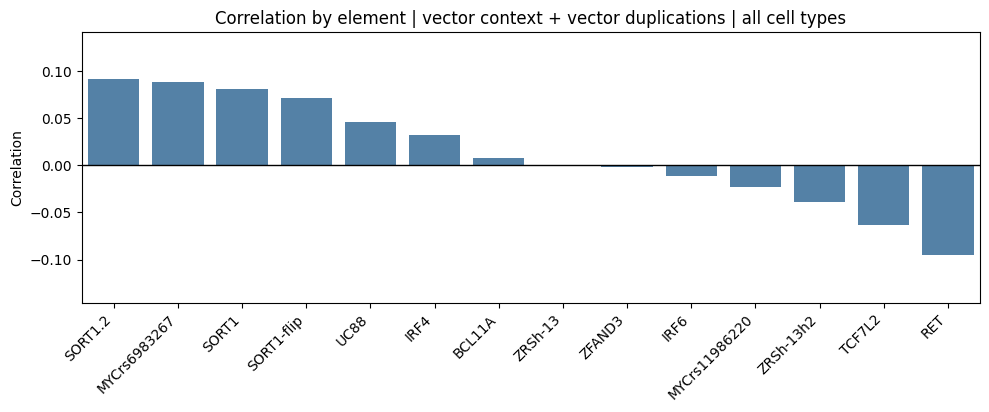

In [20]:
plot_correlations(bench.corr)

In [ ]:
bench = CAGI5_bench(model_cls='downstream_tasks.expression_prediction.expression_model_final.ExpressionCounts', 
            model_checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
            model_config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/configs/final.yaml',
            dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            desc_max_seq_len=1024,
            token_len_for_fetch=100,
            desc_tokenizer="Qwen/Qwen3-Embedding-0.6B",
            dna_max_seq_len=1024,
            num_before=511,
            celltype2desc=lookup)

**Human genome safe harbor context**

In [ ]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom',
                            padding_fn=genome_context)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

/tmp/ipykernel_2901925/3530143327.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | human safe harbor | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.278564
 6       LDLR     0.267456
 9   PKLR-24h     0.145386
 13  TERT-GSc     0.131653
 10  PKLR-48h     0.126343
 0         F9     0.114868
 11  TERT-GAa     0.093506
 12  TERT-GBM     0.082916
 5      HNF4A     0.045593
 14  TERT-HEK     0.036377
 8       MSMB    -0.001512
 1      FOXE1    -0.012501
 3        HBB    -0.053375
 4       HBG1    -0.053864
 2      GP1BA    -0.121368)

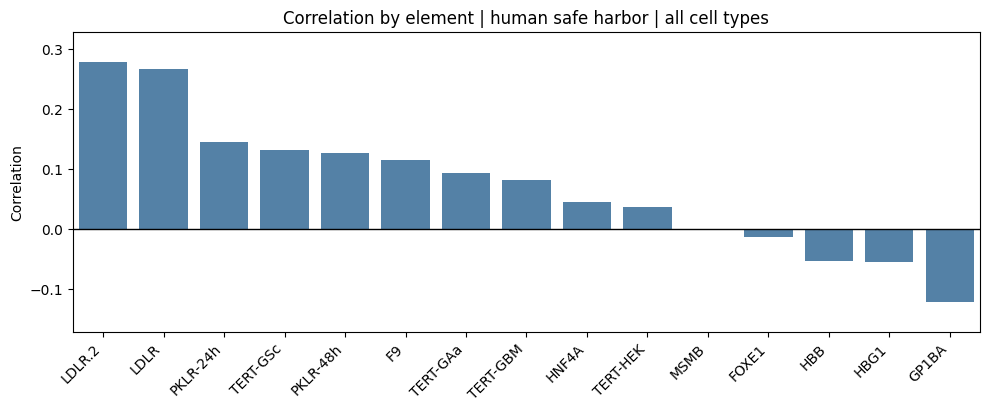

In [ ]:
#COPIED
plot_correlations(bench.corr)

**Plasmid context + safe harbor context**

In [11]:
bench.initialize_dataset(elements=ENHANCER_ELEMENTS, 
                            mode='custom', 
                            context_fn=plasmid_collection_context_NO_AUG,
                            padding_fn=genome_context)
bench.make_dataloader(batch_size=20, n_workers=5)
bench.initialize_model()
bench.run_inference()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:108: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

 34%|███▍      | 445/1309 [05:46<10:44,  1.34it/s]/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/contexts.py:454: RuntimeWarning: MCS scars overlap in the plasmid sequence; replacing the full span from left scar start to right scar end.
  edited = insert_fn(self.sequence, mpra_fragment.upper()).upper()
 34%|███▍      | 446/1309 [05:47<10:42,  1.34it/s]/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/contexts.py:454: RuntimeWarning: MCS scars overlap in the plasmid sequence; replacing the full span from left scar start to right scar end.
  edited = insert_fn(self.sequence, mpra_fragment.upper()).upper()
 34%|███▍      | 447/1309 [05:48<10:43,  1.34it/s]/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/contexts.py:454: RuntimeWarning: MCS scars overlap in the plasmid sequence; replacing the full span from left scar start to right scar end.
  edited = insert_fn(self.sequence, mpra_fragment.upper()).upper()
 34%|███▍      | 448/1309 [05:49<10:42,  1.34it/s]/workspace-SR003.nfs

/tmp/ipykernel_484229/2938281036.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | vector context + vector duplications | all cell types'}, ylabel='Correlation'>,
              name  correlation
 4    MYCrs6983267     0.103943
 7      SORT1-flip     0.090027
 8         SORT1.2     0.070404
 6           SORT1     0.069519
 5             RET     0.046646
 10           UC88     0.044266
 11         ZFAND3     0.026474
 3   MYCrs11986220     0.021896
 9          TCF7L2     0.013145
 0          BCL11A    -0.020020
 1            IRF4    -0.023788
 2            IRF6    -0.041794
 12        ZRSh-13    -0.059372
 13      ZRSh-13h2    -0.093842)

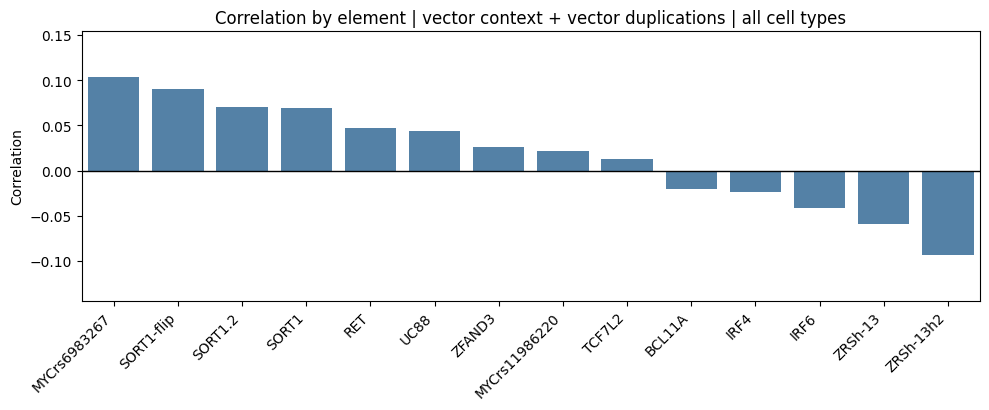

In [14]:
plot_correlations(bench.corr)

**Plasmid context + plasmid duplicaitons**

In [ ]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='custom', 
                            context_fn=plasmid_collection_context_AUG)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

/tmp/ipykernel_3047605/2938281036.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | vector context + vector duplications | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.436768
 6       LDLR     0.415405
 4       HBG1     0.097290
 3        HBB     0.054855
 0         F9     0.054413
 1      FOXE1     0.041687
 8       MSMB     0.018837
 2      GP1BA    -0.030266
 14  TERT-HEK    -0.055664
 12  TERT-GBM    -0.063293
 5      HNF4A    -0.070068
 10  PKLR-48h    -0.072113
 11  TERT-GAa    -0.072601
 13  TERT-GSc    -0.092163
 9   PKLR-24h    -0.097961)

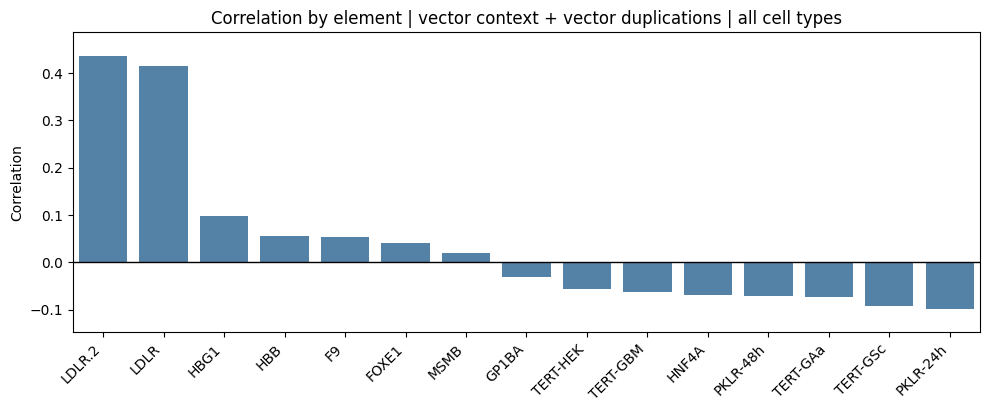

In [ ]:
#COPIED
plot_correlations(bench.corr)

**MPRA fragments in local genome context**

In [ ]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'], 
                            mode='default', 
                            length=20000)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()
bench.run_inference()

/tmp/ipykernel_3143629/4158300190.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | mpra element in local genomic context | all cell types'}, ylabel='Correlation'>,
         name  correlation
 11  TERT-GAa     0.123718
 12  TERT-GBM     0.114624
 13  TERT-GSc     0.099731
 3        HBB     0.086884
 5      HNF4A     0.074341
 14  TERT-HEK     0.039398
 1      FOXE1     0.011143
 9   PKLR-24h     0.003889
 10  PKLR-48h    -0.001287
 0         F9    -0.010895
 8       MSMB    -0.014511
 7     LDLR.2    -0.025314
 6       LDLR    -0.042679
 4       HBG1    -0.120209
 2      GP1BA    -0.136536)

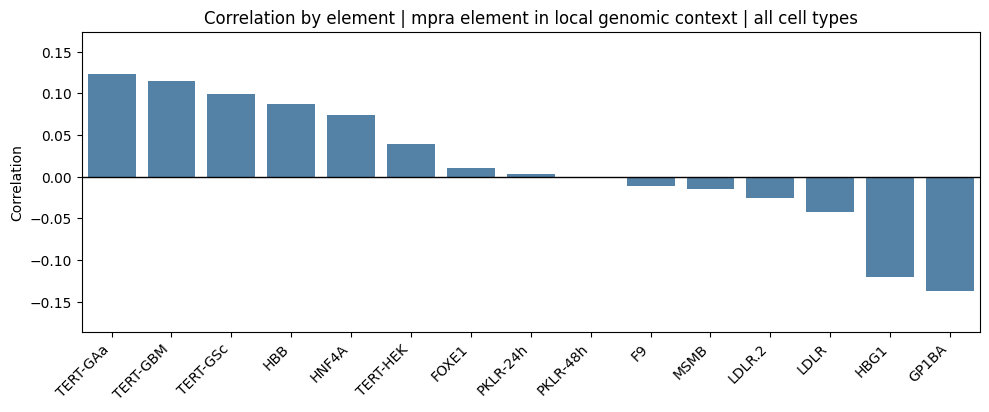

In [ ]:
#COPIED
plot_correlations(bench.corr)

In [ ]:
from __future__ import annotations

from collections.abc import Mapping
from dataclasses import dataclass, field
from pathlib import Path
from typing import TYPE_CHECKING, Any

import numpy as np
import pandas as pd

if TYPE_CHECKING:
    from matplotlib.axes import Axes
    from matplotlib.figure import Figure


Number = int | float | np.integer | np.floating


@dataclass
class VisualizationCAGI5Benchmark:
    """Visualize per-element CAGI5 Pearson correlations as table cells with bars.

    Expected input shape:
        rows    = different experiments / model settings
        columns = CAGI5 elements
        values  = Pearson correlations, usually in [-1, 1]

    `additional_values` can add external baselines such as:
        {"alphagenome": {"LDLR": 0.42, "IRF4": 0.18}}

    `type` is an optional keyword argument with per-element annotations, e.g.:
        {"LDLR": "prom.", "IRF4": "enh."}
    """

    table: pd.DataFrame | Mapping[str, Mapping[str, Any]] | str | Path
    additional_values: Mapping[str, Mapping[str, Any]] | None = None
    type: Mapping[str, str] | str | None = None
    experiment_column: str | None = None
    _table: pd.DataFrame = field(init=False, repr=False)
    _additional_values: dict[str, dict[str, Any]] = field(init=False, repr=False)

    def __post_init__(self) -> None:
        self._table = self._normalize_table(self.table, self.experiment_column)
        self._additional_values = {
            str(row_name): dict(values)
            for row_name, values in (self.additional_values or {}).items()
        }

    @classmethod
    def from_csv(
        cls,
        path: str | Path,
        *,
        additional_values: Mapping[str, Mapping[str, Any]] | None = None,
        type: Mapping[str, str] | str | None = None,
        experiment_column: str | None = None,
    ) -> "VisualizationCAGI5Benchmark":
        return cls(
            path,
            additional_values=additional_values,
            type=type,
            experiment_column=experiment_column,
        )

    @property
    def dataframe(self) -> pd.DataFrame:
        """Return the combined numeric table used for visualization."""

        return self._combined_table().copy()

    def __add__(
        self, other: "VisualizationCAGI5Benchmark"
    ) -> "VisualizationCAGI5Benchmark":
        if not isinstance(other, VisualizationCAGI5Benchmark):
            return NotImplemented

        combined = pd.concat([self._table, other._table], axis=0, sort=False)
        combined = self._deduplicate_index(combined)

        additional_values: dict[str, dict[str, Any]] = {}
        for source in (self._additional_values, other._additional_values):
            for row_name, values in source.items():
                clean_name = self._next_free_name(row_name, additional_values)
                additional_values[clean_name] = dict(values)

        return VisualizationCAGI5Benchmark(
            combined,
            additional_values=additional_values,
            type=self.type or other.type,
        )

    def plot(
        self,
        *,
        title: str | None = None,
        figsize: tuple[float, float] | None = None,
        value_range: tuple[float, float] = (-1.0, 1.0),
        cmap_positive: str = "#5f8fc8",
        cmap_negative: str = "#ff0000",
        missing_text: str = "-",
        percent: bool = True,
        decimals: int = 0,
        row_height: float = 0.42,
        col_width: float = 1.2,
        label_width: float = 3.2,
        type_height: float = 0.32,
        save_path: str | Path | None = None,
        dpi: int = 200,
        ax: "Axes | None" = None,
    ) -> "Figure":
        """Draw and optionally save the CAGI5 benchmark visualization."""

        plt, Rectangle = self._import_matplotlib()
        data = self._combined_table()
        numeric = data.apply(pd.to_numeric, errors="coerce")
        if numeric.empty:
            raise ValueError("No rows to visualize.")

        elements = list(numeric.columns)
        experiments = list(numeric.index)
        type_by_element = self._normalize_type(elements)
        has_type_row = bool(type_by_element)

        n_rows = len(experiments) + (1 if has_type_row else 0)
        n_cols = len(elements) + 1
        total_width = label_width + col_width * len(elements)
        total_height = row_height * len(experiments) + 0.7
        if has_type_row:
            total_height += type_height
        if title:
            total_height += 0.35

        if figsize is None:
            figsize = (max(8.0, total_width), max(2.6, total_height))

        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
        else:
            fig = ax.figure

        ax.set_xlim(0, total_width)
        ax.set_ylim(0, total_height)
        ax.axis("off")

        top = total_height - (0.35 if title else 0.05)
        if title:
            ax.text(
                total_width / 2,
                total_height - 0.05,
                title,
                ha="center",
                va="top",
                fontsize=13,
                fontweight="bold",
            )

        header_y = top - row_height
        self._draw_cell(ax, 0, header_y, label_width, row_height, "Experiment", bold=True)
        for j, element in enumerate(elements):
            x = label_width + j * col_width
            self._draw_cell(ax, x, header_y, col_width, row_height, str(element), bold=True)

        y = header_y
        if has_type_row:
            y -= type_height
            self._draw_cell(ax, 0, y, label_width, type_height, "Type", bold=True)
            for j, element in enumerate(elements):
                x = label_width + j * col_width
                self._draw_cell(
                    ax,
                    x,
                    y,
                    col_width,
                    type_height,
                    type_by_element.get(element, ""),
                    fontsize=9,
                )

        for i, experiment in enumerate(experiments):
            y = header_y - (type_height if has_type_row else 0) - (i + 1) * row_height
            self._draw_cell(
                ax,
                0,
                y,
                label_width,
                row_height,
                str(experiment),
                ha="left",
                xpad=0.05,
            )
            for j, element in enumerate(elements):
                x = label_width + j * col_width
                value = numeric.iloc[i, j]
                self._draw_value_cell(
                    ax,
                    x,
                    y,
                    col_width,
                    row_height,
                    value,
                    value_range=value_range,
                    positive_color=cmap_positive,
                    negative_color=cmap_negative,
                    missing_text=missing_text,
                    percent=percent,
                    decimals=decimals,
                )

        if save_path is not None:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

        return fig

    def save(self, path: str | Path, **plot_kwargs: Any) -> "Figure":
        """Convenience wrapper around `plot(save_path=...)`."""

        return self.plot(save_path=path, **plot_kwargs)

    def _combined_table(self) -> pd.DataFrame:
        table = self._table.copy()
        if self._additional_values:
            extra = pd.DataFrame.from_dict(self._additional_values, orient="index")
            table = pd.concat([table, extra], axis=0, sort=False)
        table = self._deduplicate_index(table)
        return table

    @staticmethod
    def _normalize_table(
        table: pd.DataFrame | Mapping[str, Mapping[str, Any]] | str | Path,
        experiment_column: str | None,
    ) -> pd.DataFrame:
        if isinstance(table, pd.DataFrame):
            df = table.copy()
        elif isinstance(table, (str, Path)):
            df = pd.read_csv(table)
        else:
            df = pd.DataFrame(table)
            if df.index.equals(pd.RangeIndex(len(df))):
                df = pd.DataFrame.from_dict(table, orient="index")

        if experiment_column is not None:
            if experiment_column not in df.columns:
                raise ValueError(f"Missing experiment column: {experiment_column!r}")
            df = df.set_index(experiment_column)
        elif "experiment" in df.columns:
            df = df.set_index("experiment")

        df.index = df.index.map(str)
        return df

    def _normalize_type(self, elements: list[str]) -> dict[str, str]:
        if self.type is None:
            return {}
        if isinstance(self.type, str):
            return {element: self.type for element in elements}
        return {str(element): str(value) for element, value in self.type.items()}

    @classmethod
    def _draw_cell(
        cls,
        ax: "Axes",
        x: float,
        y: float,
        width: float,
        height: float,
        text: str,
        *,
        bold: bool = False,
        fontsize: int = 10,
        ha: str = "center",
        xpad: float = 0.0,
    ) -> None:
        _, Rectangle = cls._import_matplotlib()
        ax.add_patch(
            Rectangle(
                (x, y),
                width,
                height,
                facecolor="white",
                edgecolor="#202020",
                linewidth=0.8,
            )
        )
        text_x = x + width / 2 if ha == "center" else x + xpad
        ax.text(
            text_x,
            y + height / 2,
            text,
            ha=ha,
            va="center",
            fontsize=fontsize,
            fontweight="bold" if bold else "normal",
        )

    @classmethod
    def _draw_value_cell(
        cls,
        ax: "Axes",
        x: float,
        y: float,
        width: float,
        height: float,
        value: Any,
        *,
        value_range: tuple[float, float],
        positive_color: str,
        negative_color: str,
        missing_text: str,
        percent: bool,
        decimals: int,
    ) -> None:
        _, Rectangle = cls._import_matplotlib()
        cls._draw_cell(ax, x, y, width, height, "")

        if pd.isna(value):
            ax.text(x + width / 2, y + height / 2, missing_text, ha="center", va="center")
            return

        value = float(value)
        lo, hi = value_range
        max_abs = max(abs(lo), abs(hi))
        if max_abs <= 0:
            raise ValueError("value_range must include a non-zero bound.")

        zero_x = x + width / 2
        max_bar_width = width / 2 - 0.05
        bar_width = min(abs(value) / max_abs, 1.0) * max_bar_width
        bar_height = height * 0.78
        bar_y = y + (height - bar_height) / 2

        if value >= 0:
            bar_x = zero_x
            color = positive_color
        else:
            bar_x = zero_x - bar_width
            color = negative_color

        ax.add_patch(
            Rectangle(
                (bar_x, bar_y),
                bar_width,
                bar_height,
                facecolor=color,
                edgecolor=color,
                alpha=0.9,
            )
        )
        ax.plot([zero_x, zero_x], [y, y + height], color="#202020", linewidth=0.35)

        label = cls._format_value(value, percent=percent, decimals=decimals)
        ax.text(x + width - 0.05, y + height / 2, label, ha="right", va="center", fontsize=10)

    @staticmethod
    def _format_value(value: float, *, percent: bool, decimals: int) -> str:
        if percent:
            return f"{value * 100:.{decimals}f}%"
        return f"{value:.{decimals}f}"

    @classmethod
    def _deduplicate_index(cls, df: pd.DataFrame) -> pd.DataFrame:
        counts: dict[str, int] = {}
        new_index = []
        for name in df.index.map(str):
            count = counts.get(name, 0)
            counts[name] = count + 1
            new_index.append(name if count == 0 else f"{name} ({count + 1})")
        result = df.copy()
        result.index = new_index
        return result

    @staticmethod
    def _next_free_name(name: str, existing: Mapping[str, Any]) -> str:
        if name not in existing:
            return name
        i = 2
        while f"{name} ({i})" in existing:
            i += 1
        return f"{name} ({i})"

    @staticmethod
    def _import_matplotlib() -> tuple[Any, Any]:
        try:
            import matplotlib.pyplot as plt
            from matplotlib.patches import Rectangle
        except ModuleNotFoundError as exc:
            raise ModuleNotFoundError(
                "VisualizationCAGI5Benchmark.plot() requires matplotlib. "
                "Install it with `pip install matplotlib`, or use `.dataframe` "
                "to inspect the merged benchmark table without plotting."
            ) from exc
        return plt, Rectangle


if __name__ == "__main__":
    example = pd.DataFrame(
        {
            "experiment": ["Plasmid context only", "Human genome safe harbor"],
            "LDLR": [0.51, 0.21],
            "IRF4": [0.40, -0.08],
            "BCL11A": [-0.07, 0.02],
        }
    )
    viz = VisualizationCAGI5Benchmark(
        example,
        additional_values={"alphagenome": {"LDLR": 0.44, "IRF4": 0.30}},
        type={"LDLR": "prom.", "IRF4": "enh.", "BCL11A": "enh."},
    )
    viz.save("cagi5_benchmark_example.png", title="CAGI5 Pearson Correlation")
